<a href="https://colab.research.google.com/github/MSGamgee85/MSGamgee85/blob/main/EGF_13_Trabalho_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Google Colab](https://img.shields.io/badge/Google%20Colab-F9AB00?logo=googlecolab&logoColor=fff)](#) 	[![Python](https://img.shields.io/badge/Python-3776AB?logo=python&logoColor=fff)](#) [![GitHub](https://img.shields.io/badge/GitHub-%23121011.svg?logo=github&logoColor=white)](#)

---
<h3>
<h3><b><center>Análise Setorial da Fronteira Eficiente e Simulação de Monte Carlo:<br>
uma Abordagem de Engenharia Financeira no Mercado Brasileiro</b></center><br>

---


<center><i><small> Alexandre Galetti; Fábio Henrique Costa Corrêa; Matheus Luz; Rogério Lopes; Oswaldo Diniz Soares Filho</center></i></small><br>


<center><b> Resumo </center></b>

Neste trabalho analisamos a eficiência de portfólios setoriais e os benefícios da diversificação intersetorial no mercado de capitais brasileiro, utilizando os preceitos da Teoria Moderna de Portfólios de Markowitz. O objetivo central é identificar a combinação ótima de ativos que minimize o risco para diferentes níveis de retorno esperado. A metodologia emprega a Simulação de Monte Carlo com 50.000 iterações, processadas via linguagem Python, utilizando dados diários de 16 ativos distribuídos em quatro setores estratégicos (Bancário, Energia, Commodities e Varejo) extraídos do YahooFinance entre janeiro de 2024 e dezembro de 2025. Os resultados permitiram a identificação do Portfólio de Mínima Variância (MVP) e do Portfólio de Máximo Sharpe para cada segmento. A conclusão demonstra que a diversificação entre setores com baixa correlação mitiga o risco peculiar de forma superior a portfólios intersetoriais, deslocando a fronteira eficiente para quadrantes de maior eficiência estatística, validando a premissa de que a otimização quantitativa potencializa a seleção fundamentalista prévia.

**Palavras-chave**: fronteira eficiente; análise setorial; simulação de Monte Carlo

---


In [1]:
# Bibliotecas utilizadas
import numpy as np              # funções matemáticas e operações com vetores e matrizes
import pandas as pd             # estruturas tabulares de dados
import matplotlib.pyplot as plt # geração e visualização de gráficos
import seaborn as sns           # geração de heatmaps e gráficos personalizados
import yfinance as yf           # banco de dados do mercado financeiro

In [3]:
# Configurações iniciais
ativos = ['ITUB4.SA', 'BBDC4.SA', 'BBAS3.SA', 'SANB11.SA'] # Setor Bancário
data = yf.download(ativos, start='2024-01-01', end='2025-12-30')['Close']
retornos = data.pct_change().dropna()

/tmp/ipykernel_13922/450184098.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ativos, start='2024-01-01', end='2025-12-30')['Close']
[*********************100%***********************]  4 of 4 completed


Matriz de Correlação dos Ativos:


Ticker,BBAS3.SA,BBDC4.SA,ITUB4.SA,SANB11.SA
Ticker,,,,
BBAS3.SA,1.000000,-0.626248,-0.539938,-0.290494
BBDC4.SA,-0.626248,1.000000,0.913376,0.865354
ITUB4.SA,-0.539938,0.913376,1.000000,0.800336
SANB11.SA,-0.290494,0.865354,0.800336,1.000000


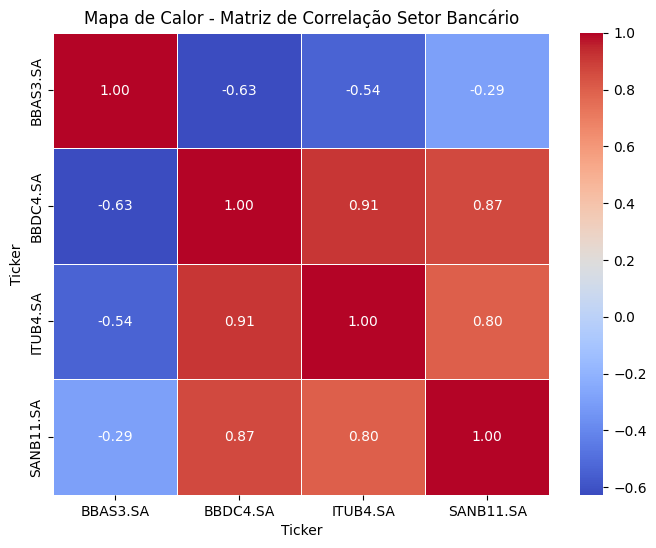

In [11]:
# Calcular a matriz de correlação
matriz_correlacao = data.corr()

# Exibir a matriz de correlação
print("Matriz de Correlação dos Ativos:")
display(matriz_correlacao)

# Gera mapa de calor da matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor - Matriz de Correlação Setor Bancário')
plt.show()

In [6]:
# Parâmetros da Simulação de Monte Carlo
num_portfolios = 10000
results = np.zeros((3, num_portfolios))
pesos_record = []

for i in range(num_portfolios):
    pesos = np.random.random(len(ativos))
    pesos /= np.sum(pesos)
    pesos_record.append(pesos)

    portfolio_retorno = np.sum(retornos.mean() * pesos) * 252
    portfolio_vol = np.sqrt(np.dot(pesos.T, np.dot(retornos.cov() * 252, pesos)))

    results[0,i] = portfolio_retorno
    results[1,i] = portfolio_vol
    results[2,i] = results[0,i] / results[1,i] # Sharpe Ratio (considerando rf=0)

In [8]:
# Localização dos portfólios ótimos
max_sharpe = np.argmax(results[2])
min_vol = np.argmin(results[1])

print("Portfólio Ótimo (Máximo Sharpe):")
print(f"μ = {results[0][max_sharpe]:.4f}")
print("Portfólio Ótimo (Mínimo Risco):")
print(f"μ = {results[0][min_vol]:.4f}")

Portfólio Ótimo (Máximo Sharpe):
μ = 0.2382
Portfólio Ótimo (Mínimo Risco):
μ = 0.1495


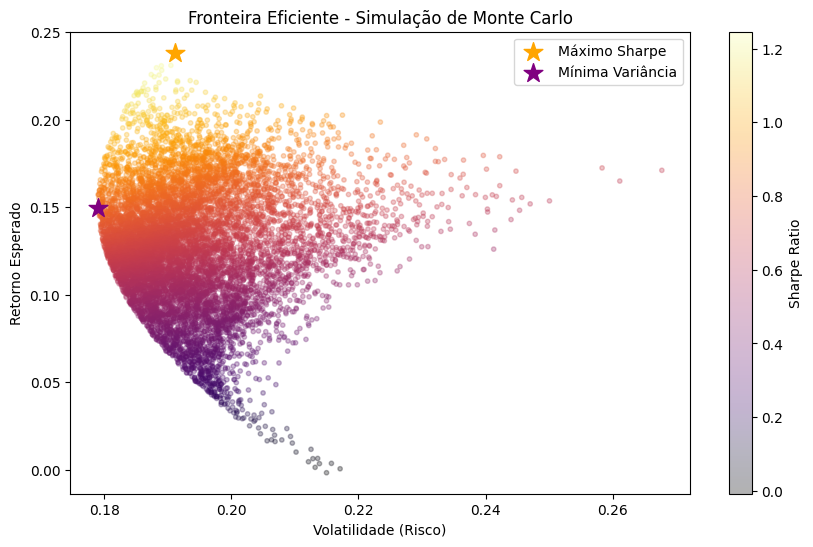

In [9]:
# Geração do Gráfico da Fronteira Eficiente
plt.figure(figsize=(10, 6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='inferno', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(results[1,max_sharpe], results[0,max_sharpe], marker='*', color='orange', s=200, label='Máximo Sharpe')
plt.scatter(results[1,min_vol], results[0,min_vol], marker='*', color='purple', s=200, label='Mínima Variância')
plt.title('Fronteira Eficiente - Simulação de Monte Carlo')
plt.xlabel('Volatilidade (Risco)')
plt.ylabel('Retorno Esperado')
plt.legend()
plt.show()

In [10]:
# Pesos do Portfólio de Máximo Sharpe
pesos_max_sharpe = pesos_record[max_sharpe]
portfolio_max_sharpe = pd.Series(pesos_max_sharpe, index=ativos)

# Pesos do Portfólio de Mínima Volatilidade
pesos_min_vol = pesos_record[min_vol]
portfolio_min_vol = pd.Series(pesos_min_vol, index=ativos)

print("Pesos do Portfólio de Máximo Sharpe:")
display(portfolio_max_sharpe.to_frame('Peso').style.format('{:.2%}'))

print("\nPesos do Portfólio de Mínima Volatilidade:")
display(portfolio_min_vol.to_frame('Peso').style.format('{:.2%}'))

Pesos do Portfólio de Máximo Sharpe:


,Peso
ITUB4.SA,0.22%
BBDC4.SA,11.77%
BBAS3.SA,82.27%
SANB11.SA,5.74%



Pesos do Portfólio de Mínima Volatilidade:


,Peso
ITUB4.SA,29.84%
BBDC4.SA,2.99%
BBAS3.SA,52.70%
SANB11.SA,14.46%
